# Max-Product Belief Propagation on chain structured Markov Random Fields for Vehicle Localization

Let's consider an autonomous vehicle driving on a highway and tracking a vehicle in front in order to initiate an overtaking maneuver. Let $x_t\in\{1,2,3\}$ denote the lane the vehicle in front is driving on at time $t\in\{1,\dots,10\}$. Unfortunately, the sensor readings are noisy as depicted below.
<img src="gfx/car_on_lane_map_unary_1.png" width="500"/>


Selecting the most likely lane at each time $t$ independently (green) leads to wrong estimates for $t=\{3,7,10\}$. To solve this problem, and recover the correct situation depicted below
<img src="gfx/car_on_lane.png" width="500"/>

we can integrate prior knowledge and infer the most likely situation using max-product belief propagation. A sensible prior would favor staying on the same lane over changing one lane at a time over changing two lanes at a time. This prior can be integrated via a pairwise, chain-structured Markov Random Field (also called: Hidden Markov Model or HMM) where pairwise factors between adjacent frames modulate transition likelihoods:
<img src="gfx/chain_10_nodes.png" width="400"/>

$$g_\theta(x_i,x_{i+1}) = \begin{bmatrix}0.8 & 0.2 & 0.0\\ 0.2 & 0.6 & 0.2 \\ 0.0 & 0.2 & 0.8\end{bmatrix}$$
$$ p_\theta({\bf x}) \propto \prod_{1}^{10} f_i(x_i)\prod_{1}^{9}g_{\theta}(x_i, x_{i+1})$$

Your task is to complete the code by implementing the specialized algorithm for max-product belief propagation on chain-structured Markov random field using backtracking. 

Let's first import the modules needed and define a helper function:

In [1]:
# import modules
import numpy as np
import matplotlib.pyplot as plt
from scipy import misc


# plot function
# input: Nx3 matrix of values & title string
def plot(vals,title=''):
    plt.close()
    vals /= np.tile(np.sum(vals,1),(3,1)).transpose()
    f, axarr = plt.subplots(1,10,figsize=(10,2))
    plt.suptitle(title, fontsize=16, fontweight='bold')
    for i in range(vals.shape[0]):
        axarr[i].barh([0,1,2],np.array([1,1,1]),color='white',edgecolor='black',linewidth=2)
        axarr[i].barh([0,1,2],vals[i],color='red')
        axarr[i].axis('off')
    plt.show()

/var/folders/9t/fp12cd9s1vv1qmyb9vz6cvwh0000gn/T/ipykernel_10893/1715279610.py:4: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  from scipy import misc


And define the potentials:

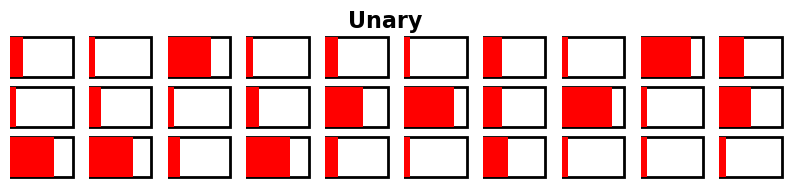

In [2]:
# unary: Nx3 matrix specifying unary likelihood of each state
unary = np.array([[0.7,0.1,0.2],[0.7,0.2,0.1],[0.2,0.1,0.7],[0.7,0.2,0.1],
                  [0.2,0.6,0.2],[0.1,0.8,0.1],[0.4,0.3,0.3],[0.1,0.8,0.1],
                  [0.1,0.1,0.8],[0.1,0.5,0.4]])
# pairwise: 3x3 matrix specifying transition probabilities (rows=t -> columns=t+1)
pairwise = np.array([[0.8,0.2,0.0],[0.2,0.6,0.2],[0.0,0.2,0.8]])

# plot unaries
plot(unary,'Unary')

### Task 1

Implement the computation of the messages between the variables below.

In [3]:
[num_vars,num_states] = unary.shape
left_right_msgs = {}

for i in range(num_vars):
    for j in range(1, 3):
      
        if j == 1:
            if i == 0:
                left_right_msgs[f"x_{i}->g"] = unary[i]
            else:
                left_right_msgs[f"x_{i}->g"] = unary[i] * left_right_msgs[f"g->x_{i}"]
        else:
            left_right_msgs[f"g->x_{i+1}"] = np.max((pairwise * left_right_msgs[f"x_{i}->g"][:, None]), axis=0)

print(left_right_msgs) 

{'x_0->g': array([0.7, 0.1, 0.2]), 'g->x_1': array([0.56, 0.14, 0.16]), 'x_1->g': array([0.392, 0.028, 0.016]), 'g->x_2': array([0.3136, 0.0784, 0.0128]), 'x_2->g': array([0.06272, 0.00784, 0.00896]), 'g->x_3': array([0.050176, 0.012544, 0.007168]), 'x_3->g': array([0.0351232, 0.0025088, 0.0007168]), 'g->x_4': array([0.02809856, 0.00702464, 0.00057344]), 'x_4->g': array([0.00561971, 0.00421478, 0.00011469]), 'g->x_5': array([0.00449577, 0.00252887, 0.00084296]), 'x_5->g': array([4.49576960e-04, 2.02309632e-03, 8.42956800e-05]), 'g->x_6': array([0.00040462, 0.00121386, 0.00040462]), 'x_6->g': array([0.00016185, 0.00036416, 0.00012139]), 'g->x_7': array([1.29478164e-04, 2.18494403e-04, 9.71086234e-05]), 'x_7->g': array([1.29478164e-05, 1.74795522e-04, 9.71086234e-06]), 'g->x_8': array([3.49591044e-05, 1.04877313e-04, 3.49591044e-05]), 'x_8->g': array([3.49591044e-06, 1.04877313e-05, 2.79672835e-05]), 'g->x_9': array([2.79672835e-06, 6.29263879e-06, 2.23738268e-05]), 'x_9->g': array([2.79

In [4]:
[num_vars,num_states] = unary.shape
right_left_msgs = {}

# Initialize missing messages with ones
for i in range(num_vars):
    if left_right_msgs.get(f"x_{i}->f") is None:
        left_right_msgs[f"x_{i}->f"] = np.ones(num_states)
    
    if left_right_msgs.get(f"x_{i}->g") is None:
        left_right_msgs[f"x_{i}->g"] = np.ones(num_states)
    
    if left_right_msgs.get(f"g->x_{i}") is None:
        left_right_msgs[f"g->x_{i}"] = np.ones(num_states)


for i in range(num_vars):
    right_left_msgs[f"x_{i}->f"] = np.ones(3,)
    right_left_msgs[f"x_{i}->g"] = np.ones(3,)
    right_left_msgs[f"g->x_{i}"] = np.ones(3,)


for i in range(num_vars-1, -1, -1):
        if i == num_vars - 1:
            right_left_msgs[f"x_{i}->f"] = left_right_msgs[f"g->x_{i}"]
            right_left_msgs[f"x_{i}->g"] = unary[i]
        else:
            right_left_msgs[f"x_{i}->f_{i}"] = left_right_msgs[f"g->x_{i}"] * right_left_msgs[f"g->x_{i}"]
            right_left_msgs[f"x_{i}->g"] = right_left_msgs[f"g->x_{i}"] * unary[i]
        if i-1 >= 0:
            right_left_msgs[f"g->x_{i-1}"] = np.max((pairwise * right_left_msgs[f"x_{i}->g"][:, None]), axis=0)

print(right_left_msgs) 

{'x_0->f': array([1., 1., 1.]), 'x_0->g': array([8.94953073e-06, 3.19626097e-07, 2.73965226e-07]), 'g->x_0': array([1.27850439e-05, 3.19626097e-06, 1.36982613e-06]), 'x_1->f': array([1., 1., 1.]), 'x_1->g': array([1.59813049e-05, 1.14152178e-06, 1.71228266e-06]), 'g->x_1': array([2.28304355e-05, 5.70760888e-06, 1.71228266e-05]), 'x_2->f': array([1., 1., 1.]), 'x_2->g': array([2.85380444e-05, 9.17294285e-06, 2.14035333e-05]), 'g->x_2': array([1.42690222e-04, 9.17294285e-05, 3.05764762e-05]), 'x_3->f': array([1., 1., 1.]), 'x_3->g': array([1.78362778e-04, 1.52882381e-04, 2.54803968e-05]), 'g->x_3': array([0.0002548 , 0.00076441, 0.0002548 ]), 'x_4->f': array([1., 1., 1.]), 'x_4->g': array([0.00014156, 0.00127402, 0.00014156]), 'g->x_4': array([0.00070779, 0.00212337, 0.00070779]), 'x_5->f': array([1., 1., 1.]), 'x_5->g': array([0.00026214, 0.00353894, 0.00039322]), 'g->x_5': array([0.00262144, 0.00442368, 0.00393216]), 'x_6->f': array([1., 1., 1.]), 'x_6->g': array([0.0032768, 0.0073728,

### Task 2

Use dynamic programming to calculate and plot the MAP solution.

**Outputs:**
 * `max_marginals`: `num_vars` x `num_states` array of estimated max-marginals
 * `map`: array comprising the estimated MAP state of each variable

In [5]:
# calculate max-marginals (num_vars x num_states matrix) and MAP estimates (num_vars x 1 matrix)
max_marginals = np.zeros([num_vars,num_states])
map = np.zeros(num_vars, dtype=int)
dp = np.zeros([num_vars, num_states])
for i in range(num_vars):
    max_marginals[i] = left_right_msgs[f"g->x_{i}"] * right_left_msgs[f"g->x_{i}"] * unary[i]
    map[i] = np.argmax(max_marginals[i])

print(f"map: {map}")
print(f"max_marginals: \n{max_marginals}")


map: [0 0 0 0 1 1 1 1 2 2]
max_marginals: 
[[8.94953073e-06 3.19626097e-07 2.73965226e-07]
 [8.94953073e-06 1.59813049e-07 2.73965226e-07]
 [8.94953073e-06 7.19158719e-07 2.73965226e-07]
 [8.94953073e-06 1.91775658e-06 1.82643484e-07]
 [3.97756921e-06 8.94953073e-06 8.11748819e-08]
 [1.17853903e-06 8.94953073e-06 3.31464101e-07]
 [1.32585640e-06 8.94953073e-06 1.98878461e-06]
 [1.03582532e-07 8.94953073e-06 1.98878461e-06]
 [3.49591044e-07 3.14631940e-06 8.94953073e-06]
 [2.79672835e-07 3.14631940e-06 8.94953073e-06]]


Visualize and print the results:

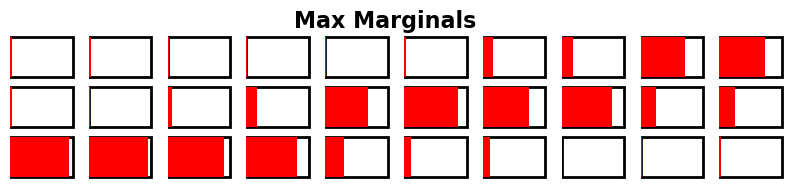

MAP Estimate:
[0 0 0 0 1 1 1 1 2 2]


In [6]:
# plot max-marginals
plot(max_marginals,'Max Marginals')

# print MAP state
print("MAP Estimate:")
print(np.argmax(max_marginals,axis=1))